## Probability Intuition via Simulation

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import norm

# ── Reproducible randomness ───────────────────────────────────────────
# We set a seed so everyone gets the same results.
# In real Monte Carlo work, you'd run without a seed and average over many seeds.
RNG = np.random.default_rng(seed=42)

# ── Plot style ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"]    = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Setup complete.")

Setup complete.


## Exercise 1
##### A six-sided die is rolled. Simulate the probability of rolling a 5 or 6 for increasing numbers of rolls: [10, 100, 1000, 10000, 100000].

- Plot the empirical probability as a function of the number of rolls (use a log x-axis)
- Add a horizontal dashed line at the true probability
- Print the error at each sample size

##### Hint — roll a die:
- RNG.integers(1, 7, size=N)   →  values in {1, 2, 3, 4, 5, 6}
- true probability of 5 or 6 = 2/6 = 1/3

Sample Size:      10 | Absolute Error: 0.033333
Sample Size:     100 | Absolute Error: 0.066667
Sample Size:   1,000 | Absolute Error: 0.002667
Sample Size:  10,000 | Absolute Error: 0.006533
Sample Size: 100,000 | Absolute Error: 0.000657


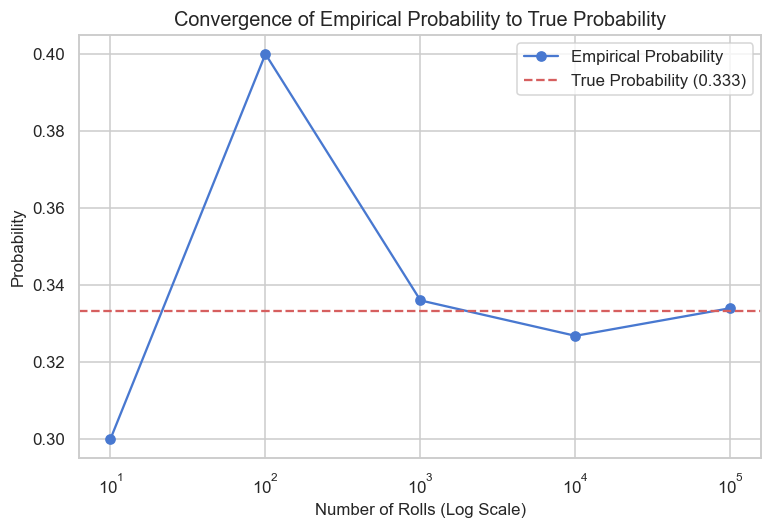

In [25]:
RNG = np.random.default_rng(seed=42)

sample_sizes = np.array([10, 100, 1000, 10000, 100000])
max_rolls = sample_sizes[-1]
rolls = RNG.integers(1, 7, size=max_rolls)


is_5_or_6 = (rolls == 5) | (rolls == 6)
cumulative_successes = np.cumsum(is_5_or_6)
successes_at_sizes = cumulative_successes[sample_sizes - 1]
empirical_probabilities = successes_at_sizes / sample_sizes

true_probability = 1 / 3
errors = np.abs(empirical_probabilities - true_probability)

for size, err in zip(sample_sizes, errors):
    print(f"Sample Size: {size:7,} | Absolute Error: {err:.6f}")


plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, empirical_probabilities, marker='o', linestyle='-', color='b', label='Empirical Probability')
plt.axhline(y=true_probability, color='r', linestyle='--', label=f'True Probability ({true_probability:.3f})')
plt.xscale('log')
plt.xlabel('Number of Rolls (Log Scale)')
plt.ylabel('Probability')
plt.title('Convergence of Empirical Probability to True Probability')
plt.legend()
plt.show()


### Exercise 2
#### The Poisson distribution with λ=3 is discrete and right-skewed.

- Draw n_experiments = 3000 sample means for n ∈ {1, 10, 50}
- Plot histograms with a fitted normal curve overlay
- At what value of n does the distribution look approximately normal to you?
##### Hint:
- RNG.poisson(lam=3, size=n)   →  Poisson(λ=3) sample of size n
- True mean = λ = 3,   True variance = λ = 3

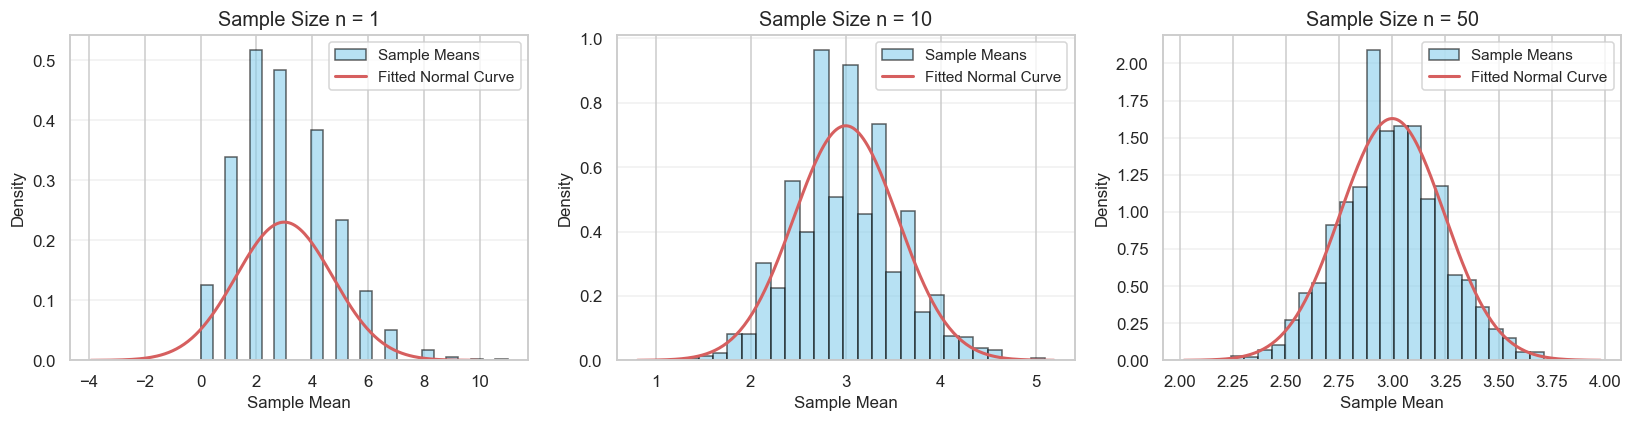

In [26]:
RNG = np.random.default_rng(seed=42)
n_experiments = 3000
lam = 3


means_n1  = np.mean(RNG.poisson(lam=lam, size=(n_experiments, 1)), axis=1)
means_n10 = np.mean(RNG.poisson(lam=lam, size=(n_experiments, 10)), axis=1)
means_n50 = np.mean(RNG.poisson(lam=lam, size=(n_experiments, 50)), axis=1)

plot_data = [(1, means_n1), (10, means_n10), (50, means_n50)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (n, data) in zip(axes, plot_data):
    counts, bins, _ = ax.hist(data, bins=25, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Sample Means')
    
    mu_true = lam
    sigma_true = np.sqrt(lam / n)
    x = np.linspace(mu_true - 4*sigma_true, mu_true + 4*sigma_true, 200)
    ax.plot(x, norm.pdf(x, mu_true, sigma_true), 'r-', lw=2, label='Fitted Normal Curve')
    
    ax.set_title(f'Sample Size n = {n}')
    ax.set_xlabel('Sample Mean')
    ax.set_ylabel('Density')
    ax.legend(fontsize='small')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Exercise 3
#### Extend the Gambler's Ruin to an unfair coin with  𝑃(win)=𝑝=0.45  (like a casino game).

- The analytical win probability for a biased coin is:
𝑃(win∣𝑘)=1−(𝑞/𝑝)𝑘1−(𝑞/𝑝)𝑁,𝑞=1−𝑝 

- Simulate 5,000 games for k in range(1, 20) with N=20, p=0.45
- Plot simulated vs analytical win probability
- Compare the plot to the fair-coin case above. What do you notice?
##### Hint — biased coin step:
- step = RNG.choice([-1, 1], p=[1-p_win, p_win])

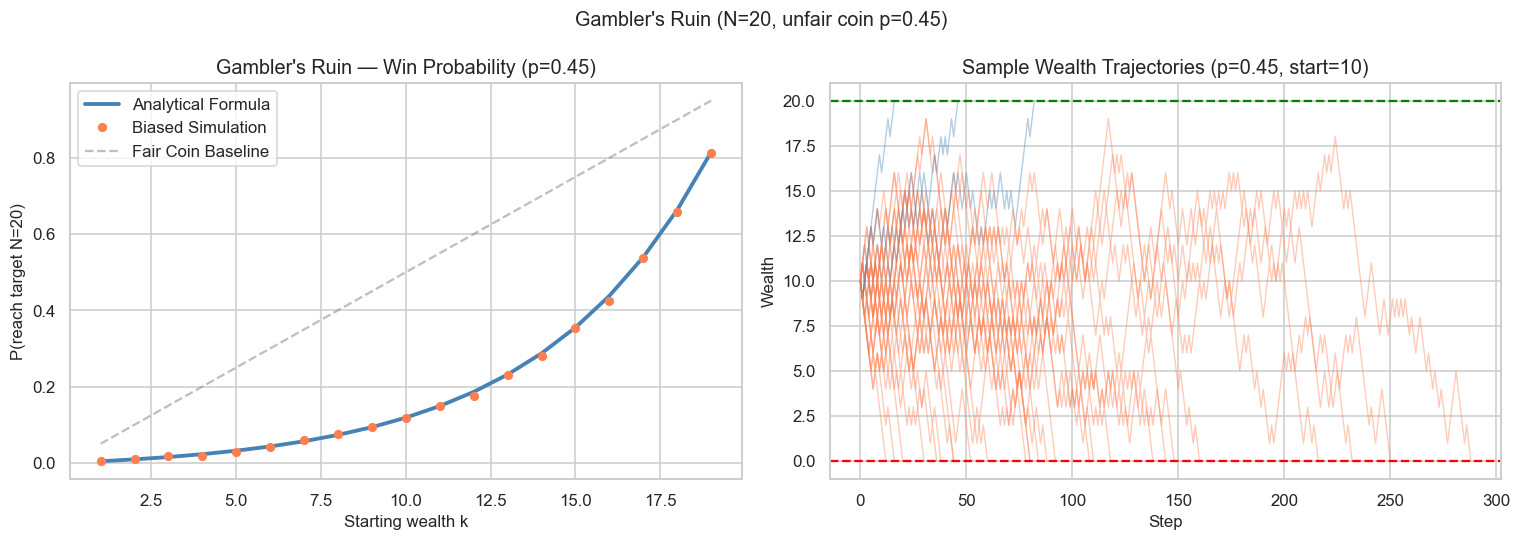

In [27]:
RNG = np.random.default_rng(seed=42)

def gambler_ruin_biased_sim(start, target, p_win=0.45, n_games=5000):
    """Simulate n_games of Gambler's Ruin with a biased coin."""
    wins = 0
    q = 1 - p_win
    for _ in range(n_games):
        wealth = start
        while 0 < wealth < target:
            wealth += RNG.choice([-1, 1], p=[q, p_win])   
        if wealth == target:
            wins += 1
    return wins / n_games

N = 20
p = 0.45
q = 1 - p
starts = range(1, N)

sim_probs = [gambler_ruin_biased_sim(k, N, p_win=p) for k in starts]
exact = [(1 - (q / p)**k) / (1 - (q / p)**N) for k in starts]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(starts, exact, color="steelblue", linewidth=2.5, label="Analytical Formula")
axes[0].plot(starts, sim_probs, "o", color="coral", markersize=5, label="Biased Simulation")
axes[0].plot(starts, [k/N for k in starts], "--", color="gray", alpha=0.5, label="Fair Coin Baseline")
axes[0].set_xlabel("Starting wealth k")
axes[0].set_ylabel("P(reach target N=20)")
axes[0].set_title("Gambler's Ruin — Win Probability (p=0.45)")
axes[0].legend()

axes[1].set_title("Sample Wealth Trajectories (p=0.45, start=10)")
for _ in range(30):
    wealth = 10
    path = [wealth]
    while 0 < wealth < 20 and len(path) < 400:
        wealth += RNG.choice([-1, 1], p=[q, p])
        path.append(wealth)
    color = "steelblue" if path[-1] == 20 else "coral"
    axes[1].plot(path, color=color, alpha=0.4, linewidth=0.9)

axes[1].axhline(20, color="green", linestyle="--")
axes[1].axhline(0,  color="red",   linestyle="--")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Wealth")

plt.suptitle("Gambler's Ruin (N=20, unfair coin p=0.45)", fontsize=13)
plt.tight_layout()
plt.show()
